## Simple script to obtain embeddings from arbitrary size images and prepare for cEBMF

In [1]:
import torch
from torchvision import transforms
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import numpy as np
import os
import tqdm
from tqdm import tqdm
import timm
from huggingface_hub import login, hf_hub_download
from cebmf_torch import cEBMF
from cebmf_torch.torch_main import ModelParams, NoiseParams, CovariateParams
import matplotlib.pyplot as plt

/Users/thomasmonahan/Documents/GitHub/cebmf_torch/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
login('')

In [3]:
### Load data
# images = images
# locs = locations x,y
# ged = gene expression

dir1 = '../../../Desktop/data/gene_expression_dataset.pt'
dir2 = '../../../Desktop/data/subimg_coord_dataset.pt'

ged = torch.load(dir1)
scd = torch.load(dir2)
images = []
locs = []
for img, loc in scd:
    images.append(img)
    locs.append(loc)

images = torch.stack(images)
locs = torch.stack(locs)

In [4]:
def get_clip_embedding(image_input, model, processor, device):
    """
    Takes a file path, PIL.Image, or torch.Tensor and returns a 512-dim CLIP embedding.
    - Handles grayscale [1,H,W] tensors by repeating channels → [3,H,W].
    - Works on GPU without unnecessary CPU/NumPy conversions.
    """
    # Case 1: file path
    if isinstance(image_input, str):
        image = Image.open(image_input).convert("RGB")

    # Case 2: PIL image
    elif isinstance(image_input, Image.Image):
        if image_input.mode != "RGB":
            image = image_input.convert("RGB")
        else:
            image = image_input

    # Case 3: torch tensor
    elif isinstance(image_input, torch.Tensor):
        image = image_input
        if image.ndim == 4:  # [B,C,H,W], reduce to batch size 1 if needed
            if image.shape[0] == 1:
                image = image.squeeze(0)
            else:
                raise ValueError("Batch tensors not supported here. Pass single image.")
        if image.ndim != 3:
            raise ValueError(f"Expected [C,H,W] tensor, got shape {image.shape}")

        # Grayscale → RGB by channel repeat
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)

        # Convert tensor to PIL (processor expects PIL or numpy),
        # but keep data on CPU just before feeding
        image = transforms.ToPILImage()(image.cpu())

    else:
        raise TypeError(f"Unsupported input type: {type(image_input)}")

    # Process and get embedding
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        image_emb = model.get_image_features(**inputs)
        image_emb = image_emb / image_emb.norm(p=2, dim=-1, keepdim=True)  # normalize

    return image_emb.squeeze(0)  # shape: (512,)


### Step 1: Load images and get CLIP embeddings

In [5]:
# Load pretrained CLIP
device = "mps" if torch.mps.is_available() else "cpu"
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clip_embedded_images = []
for image in tqdm(images):
    tempimage = image.squeeze(0).to(device)
    feature_emb = get_clip_embedding(tempimage, clip_model, clip_processor, device) # Extracted features (torch.Tensor) with shape [1,1536]
    clip_embedded_images.append(feature_emb)

clip_embedded_images = torch.stack(clip_embedded_images)  # shape (N, 512)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
100%|███████████████████████████████████████████| 100/100 [00:01<00:00, 91.16it/s]


### Load images and get UNI embeddings

In [6]:
local_dir = "../assets/ckpts/uni2-h/"
os.makedirs(local_dir, exist_ok=True)  # create directory if it does not exist
hf_hub_download("MahmoodLab/UNI2-h", filename="pytorch_model.bin", local_dir=local_dir, force_download=True)
timm_kwargs = {
            'model_name': 'vit_giant_patch14_224',
            'img_size': 224, 
            'patch_size': 14, 
            'depth': 24,
            'num_heads': 24,
            'init_values': 1e-5, 
            'embed_dim': 1536,
            'mlp_ratio': 2.66667*2,
            'num_classes': 0, 
            'no_embed_class': True,
            'mlp_layer': timm.layers.SwiGLUPacked, 
            'act_layer': torch.nn.SiLU, 
            'reg_tokens': 8, 
            'dynamic_img_size': True
        }
uni_model = timm.create_model(
    pretrained=False, **timm_kwargs
)
uni_model.load_state_dict(torch.load(os.path.join(local_dir, "pytorch_model.bin"), map_location="cpu"), strict=True)

<All keys matched successfully>

In [7]:
import torch
from torchvision import transforms
from PIL import Image

def get_uni_embedding(image_input, model, device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Takes a file path, PIL.Image, or single-channel tensor, returns a Uni embedding.
    Automatically converts grayscale images to 3-channel RGB and resizes/crops to 224x224.
    
    Returns:
        torch.Tensor of shape [embedding_dim], e.g., [1536]
    """
    # Load image if a file path is provided
    if isinstance(image_input, str):
        image = Image.open(image_input)
    else:
        image = image_input

    # Convert torch tensor to PIL.Image if needed
    if isinstance(image, torch.Tensor):
        if image.ndim == 4 and image.shape[0] == 1:  # [1,C,H,W]
            image = image.squeeze(0)
        if image.ndim == 3:  # [C,H,W]
            if image.shape[0] == 1:  # grayscale
                img_np = (image[0].cpu().numpy() * 255).astype("uint8")
                image = Image.fromarray(img_np).convert("RGB")
            elif image.shape[0] == 3:  # already RGB
                img_np = (image.permute(1,2,0).cpu().numpy() * 255).astype("uint8")
                image = Image.fromarray(img_np)
            else:
                raise ValueError(f"Unexpected number of channels: {image.shape[0]}")
        else:
            raise ValueError(f"Expected 3D tensor [C,H,W], got {image.ndim}D")

    # Convert grayscale PIL images to RGB
    if image.mode != "RGB":
        image = image.convert("RGB")

    # Transform: resize, center crop, normalize (ImageNet-style)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Uni expects 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)  # [1,3,224,224]

    model.eval()
    with torch.inference_mode():
        embedding = model(image_tensor)  # [1, feature_dim], e.g., [1,1536]
        embedding = embedding / embedding.norm(p=2, dim=-1, keepdim=True)  # normalize

    return embedding.squeeze(0)  # shape: [feature_dim]


In [8]:
uni_embedded_images = []
for image in tqdm(images):
    tempimage = image.squeeze(0)
    with torch.inference_mode():
        feature_emb = get_uni_embedding(tempimage, uni_model, device = 'cpu') # For some reason this is much happier on cpu?
        uni_embedded_images.append(feature_emb)
uni_embedded_images = torch.stack(uni_embedded_images)

100%|███████████████████████████████████████████| 100/100 [00:45<00:00,  2.20it/s]


In [9]:
Y = torch.stack(ged)
locs = locs.to(clip_embedded_images.device, dtype=clip_embedded_images.dtype)

cov_inputs_clip  = torch.cat([clip_embedded_images, locs], dim=1)
cov_inputs_uni = torch.cat([uni_embedded_images.to(device), locs], dim=1)   # shape (N, C*H*W + P)

reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 259.2823
[EGNNMDN] Epoch 20/50, Loss: 213.3811
[EGNNMDN] Epoch 30/50, Loss: 173.9958
[EGNNMDN] Epoch 40/50, Loss: 140.3522
[EGNNMDN] Epoch 50/50, Loss: 111.7470


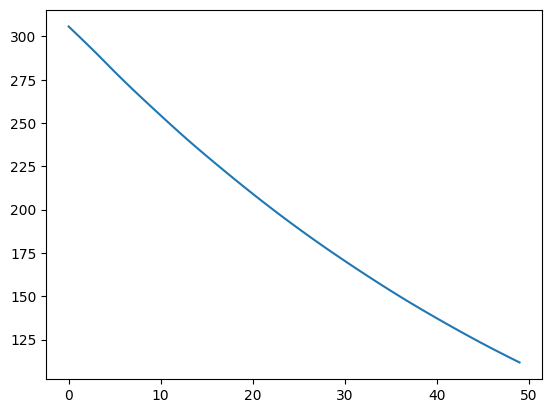

[update L0] post_mean mean=-26.4335, std=2.4799, min=-30.1064, max=-17.6895
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 9.1228
[EGNNMDN] Epoch 20/50, Loss: 7.6015
[EGNNMDN] Epoch 30/50, Loss: 6.4073
[EGNNMDN] Epoch 40/50, Loss: 5.4626
[EGNNMDN] Epoch 50/50, Loss: 4.7136


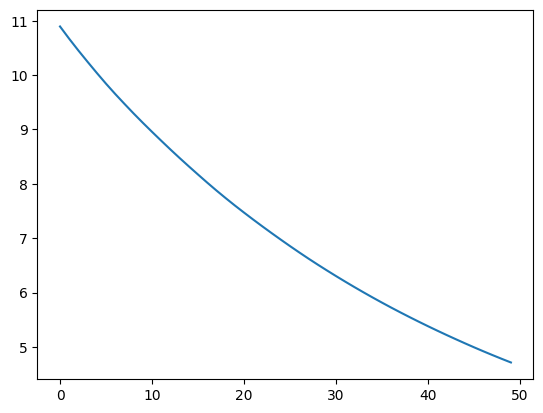

[update L1] post_mean mean=0.3817, std=5.2503, min=-11.7257, max=10.2724
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 7.1510
[EGNNMDN] Epoch 20/50, Loss: 6.2386
[EGNNMDN] Epoch 30/50, Loss: 5.4397
[EGNNMDN] Epoch 40/50, Loss: 4.7701
[EGNNMDN] Epoch 50/50, Loss: 4.2452


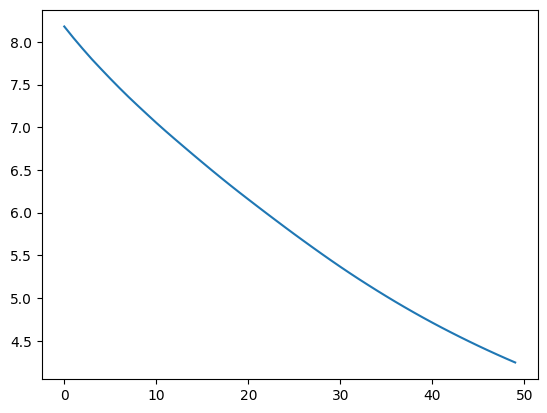

[update L2] post_mean mean=-0.1325, std=4.2407, min=-16.6899, max=7.0269
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 5.2148
[EGNNMDN] Epoch 20/50, Loss: 4.1494
[EGNNMDN] Epoch 30/50, Loss: 3.3741
[EGNNMDN] Epoch 40/50, Loss: 2.8540
[EGNNMDN] Epoch 50/50, Loss: 2.5447


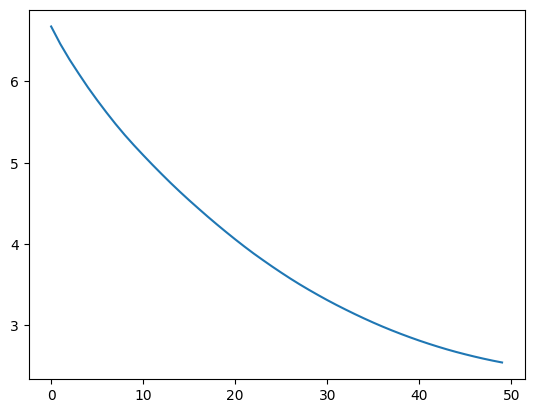

[update L3] post_mean mean=0.0745, std=4.2249, min=-10.1053, max=22.5007
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 7.2579
[EGNNMDN] Epoch 20/50, Loss: 6.2292
[EGNNMDN] Epoch 30/50, Loss: 5.4348
[EGNNMDN] Epoch 40/50, Loss: 4.7164
[EGNNMDN] Epoch 50/50, Loss: 4.0658


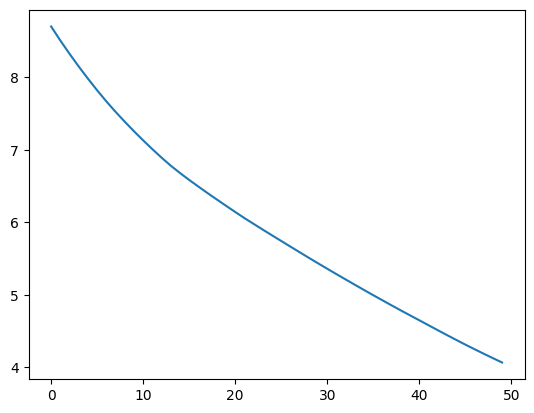

[update L4] post_mean mean=0.0312, std=4.1414, min=-17.8280, max=13.7275
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 4.5304
[EGNNMDN] Epoch 20/50, Loss: 3.4207
[EGNNMDN] Epoch 30/50, Loss: 2.7650
[EGNNMDN] Epoch 40/50, Loss: 2.3935
[EGNNMDN] Epoch 50/50, Loss: 2.2315


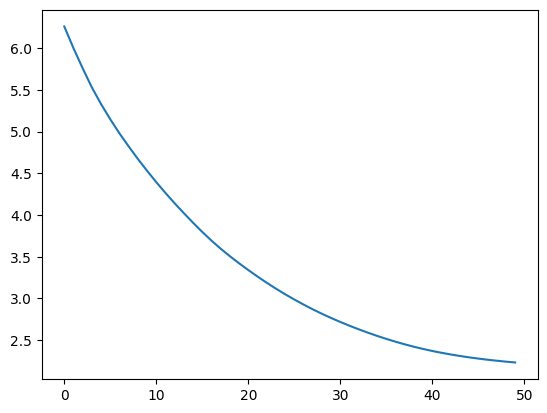

[update L5] post_mean mean=-0.0593, std=4.1635, min=-20.3837, max=17.7576
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 6.2783
[EGNNMDN] Epoch 20/50, Loss: 5.1218
[EGNNMDN] Epoch 30/50, Loss: 4.1790
[EGNNMDN] Epoch 40/50, Loss: 3.4633
[EGNNMDN] Epoch 50/50, Loss: 3.0080


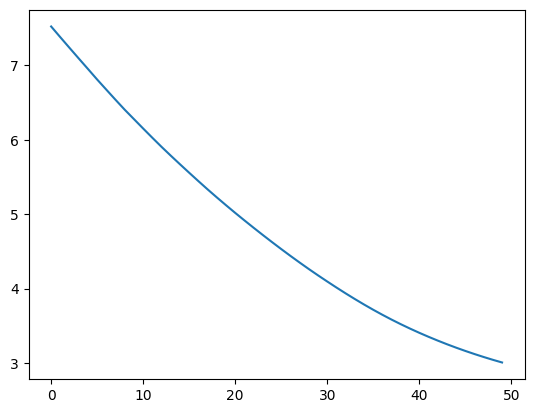

[update L6] post_mean mean=-0.0155, std=4.1212, min=-14.4110, max=17.9439
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 4.4447
[EGNNMDN] Epoch 20/50, Loss: 3.5186
[EGNNMDN] Epoch 30/50, Loss: 3.0114
[EGNNMDN] Epoch 40/50, Loss: 2.7159
[EGNNMDN] Epoch 50/50, Loss: 2.5669


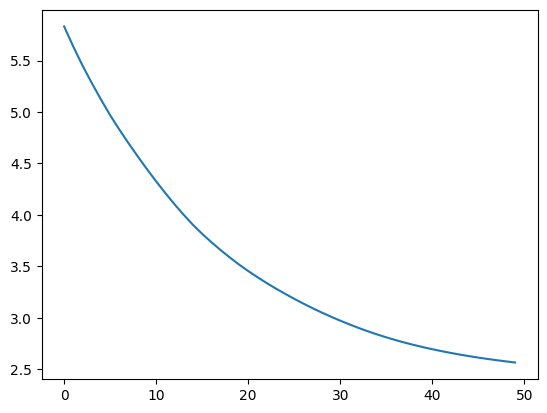

[update L7] post_mean mean=-0.0139, std=4.0991, min=-18.9271, max=11.8635
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 4.9880
[EGNNMDN] Epoch 20/50, Loss: 4.0969
[EGNNMDN] Epoch 30/50, Loss: 3.5180
[EGNNMDN] Epoch 40/50, Loss: 3.1232
[EGNNMDN] Epoch 50/50, Loss: 2.8543


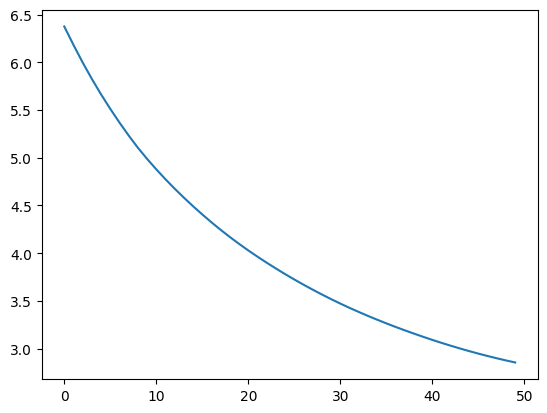

[update L8] post_mean mean=0.0004, std=4.0741, min=-13.8235, max=12.7560
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 5.8247
[EGNNMDN] Epoch 20/50, Loss: 4.7135
[EGNNMDN] Epoch 30/50, Loss: 3.9098
[EGNNMDN] Epoch 40/50, Loss: 3.3035
[EGNNMDN] Epoch 50/50, Loss: 2.8867


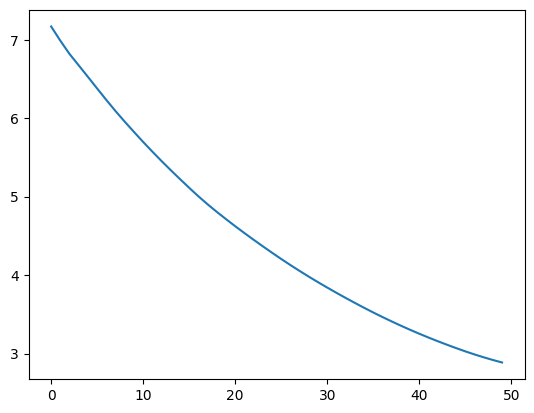

[update L9] post_mean mean=0.0536, std=4.0549, min=-10.1796, max=14.2683
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 216.4775
[EGNNMDN] Epoch 20/50, Loss: 161.6239
[EGNNMDN] Epoch 30/50, Loss: 115.9887
[EGNNMDN] Epoch 40/50, Loss: 79.1928
[EGNNMDN] Epoch 50/50, Loss: 51.6669


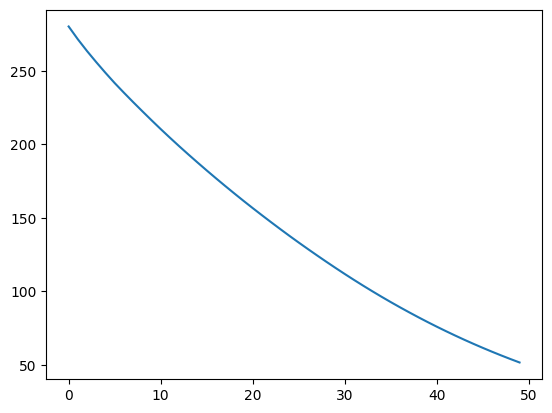

[update L0] post_mean mean=-26.6902, std=2.5871, min=-30.2029, max=-17.9126
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 10.1304
[EGNNMDN] Epoch 20/50, Loss: 8.2366
[EGNNMDN] Epoch 30/50, Loss: 6.6892
[EGNNMDN] Epoch 40/50, Loss: 5.4494
[EGNNMDN] Epoch 50/50, Loss: 4.5585


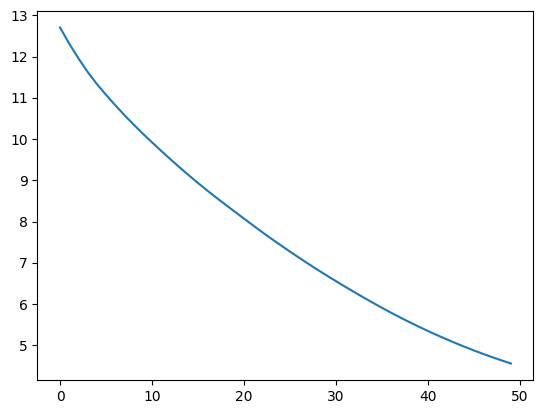

[update L1] post_mean mean=0.3712, std=5.2634, min=-11.7557, max=10.2960
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 5.7073
[EGNNMDN] Epoch 20/50, Loss: 4.5248
[EGNNMDN] Epoch 30/50, Loss: 3.8272
[EGNNMDN] Epoch 40/50, Loss: 3.4205
[EGNNMDN] Epoch 50/50, Loss: 3.1991


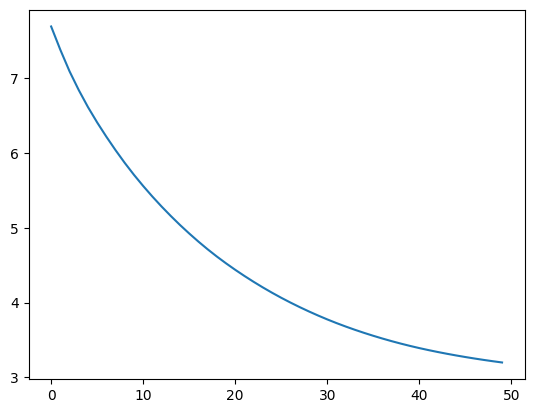

[update L2] post_mean mean=-0.1380, std=4.2731, min=-16.7111, max=7.0781
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 6.1564
[EGNNMDN] Epoch 20/50, Loss: 4.5197
[EGNNMDN] Epoch 30/50, Loss: 3.4368
[EGNNMDN] Epoch 40/50, Loss: 2.8026
[EGNNMDN] Epoch 50/50, Loss: 2.5059


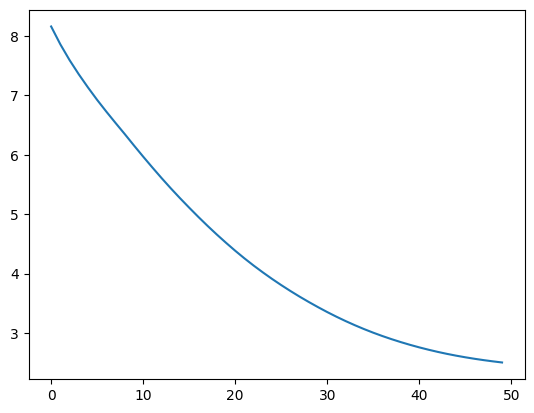

[update L3] post_mean mean=0.0798, std=4.2292, min=-10.1095, max=22.4986
reg strength: 0.0
[EGNNMDN] Epoch 10/50, Loss: 4.5512
[EGNNMDN] Epoch 20/50, Loss: 3.3014
[EGNNMDN] Epoch 30/50, Loss: 2.7500
[EGNNMDN] Epoch 40/50, Loss: 2.5782
[EGNNMDN] Epoch 50/50, Loss: 2.5299


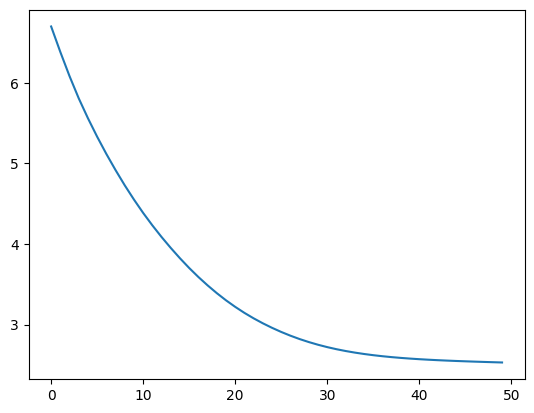

[update L4] post_mean mean=0.0276, std=4.1955, min=-18.0942, max=13.7593


In [ ]:
model_params_clip = ModelParams(prior_L="egnnmdn", prior_F="norm", K=10)

model_params_uni = ModelParams(prior_L="egnnmdn", prior_F="norm", K=10)

covars_clip = CovariateParams(X_l = cov_inputs_clip.to('cpu'), X_f = torch.ones(Y.shape[1]), self_row_cov = True, self_col_cov = False)
covars_uni = CovariateParams(X_l = cov_inputs_uni.to('cpu'), X_f = torch.ones(Y.shape[1]), self_row_cov = True, self_col_cov = False)

cebmf_model_clip = cEBMF(data=Y.to('cpu'), model=model_params_clip, covariate = covars_clip)
cebmf_model_uni = cEBMF(data=Y.to('cpu'), model=model_params_uni, covariate = covars_uni)

# Fit
fit_clip = cebmf_model_clip.fit(maxit=1)
fit_uni = cebmf_model_uni.fit(maxit=1)

In [ ]:
clip_recon = (fit_clip.L @ fit_clip.F.T)
clip_mse = (Y - clip_recon)**2

uni_recon = (fit_uni.L @ fit_uni.F.T)
uni_mse = (Y - uni_recon)**2

plt.scatter(clip_recon.numpy().flatten()[:], Y.numpy().flatten()[:], label = f'CLIP: mu: {torch.mean(clip_mse):.6f}, med: {torch.median(clip_mse):.6f}')
plt.scatter(uni_recon.numpy().flatten()[:], Y.numpy().flatten()[:], label = f'UNI-h: mu: {torch.mean(uni_mse):.6f}, med: {torch.median(uni_mse):.6f}')

plt.legend()
plt.show()

In [ ]:
cov_inputs1  = torch.cat([clip_embedded_images[:50], locs[:50]], dim=1)
cov_inputs2 = torch.cat([clip_embedded_images.to(device)[50:], locs[50:]], dim=1)   # shape (N, C*H*W + P)

In [ ]:
# Slice 1
cov_inputs1 = torch.cat([clip_embedded_images[:50], locs[:50]], dim=1)   # (50, 514)
slice_indicator1 = torch.zeros(cov_inputs1.size(0), 1, device=cov_inputs1.device)
cov_inputs1 = torch.cat([cov_inputs1, slice_indicator1], dim=1)          # (50, 515)

# Slice 2
cov_inputs2 = torch.cat([clip_embedded_images[50:], locs[50:]], dim=1)   # (50, 514)
slice_indicator2 = torch.ones(cov_inputs2.size(0), 1, device=cov_inputs2.device)
cov_inputs2 = torch.cat([cov_inputs2, slice_indicator2], dim=1)          # (50, 515)

# Combine
cov_inputs = torch.cat([cov_inputs1, cov_inputs2], dim=0)                # (100, 515)


In [ ]:
model_params_separable = ModelParams(prior_L="egnnmdnseparable", prior_F="norm", K=10)


covars_separable = CovariateParams(X_l = cov_inputs.to('cpu'), X_f = torch.ones(Y.shape[1]), self_row_cov = True, self_col_cov = False)

cebmf_model_clip = cEBMF(data=Y.to('cpu'), model=model_params_separable, covariate = covars_separable)

# Fit
fit_separable = cebmf_model_clip.fit(maxit=1)